# Housing Dataset Analysis
**Dataset:** Preprocessed_dataset_knn_5neighbour_.csv  
**Tasks:** Descriptive Statistics | House Age Feature | ANOVA & VIF

In [30]:
import pandas as pd
import numpy as np
import warnings
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')

# Scipy
from scipy import stats
from scipy.stats import f_oneway, levene

# Statsmodels VIF (with pure-numpy fallback)
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    from statsmodels.tools.tools import add_constant
    _USE_STATSMODELS = True
except ImportError:
    _USE_STATSMODELS = False
    print('statsmodels not found — using numpy VIF fallback.')

    def add_constant(df):
        out = df.copy()
        out.insert(0, 'const', 1.0)
        return out

    def variance_inflation_factor(X, idx):
        '''Pure-numpy VIF: regress column idx on all others, return 1/(1-R²).'''
        y = X[:, idx]
        X_other = np.delete(X, idx, axis=1)
        # OLS via normal equations
        try:
            coef, _, _, _ = np.linalg.lstsq(X_other, y, rcond=None)
            y_hat = X_other @ coef
            ss_res = np.sum((y - y_hat) ** 2)
            ss_tot = np.sum((y - y.mean()) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
            return 1 / (1 - r2) if r2 < 1 else np.inf
        except Exception:
            return np.nan

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)

print('All libraries loaded successfully.')

All libraries loaded successfully.


## Load the Dataset

In [3]:
df = pd.read_csv('/content/Preprocessed_dataset_knn(5neighbour).csv', low_memory=False)

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print()
df.head()

Shape: 51,934 rows × 22 columns



,Reporting Period,Project ID,Project County,Project City,Project ZIP,Gas Utility,Electric Utility,Project Completion Date,Total Project Cost,Pre-Retrofit Home Heating Fuel Type,Year Home Built,Size Of Home,Number Of Units,Job Type,Type Of Dwelling,Measure Type,Estimated Annual kWh Savings,Estimated Annual MMBtu Savings,First Year Modeled Project Energy Savings $ Estimate,size_of_home_flag,Location_1_latitude,Location_1_Longitude
0,2023-06-30,577366,Broome,Endicott,13760,New York State Electric & Gas,New York State Electric & Gas,2023-06-22,9661.0000,Oil,1960,1484,1,Home Performance,Single Family,Building Shell,277.0000,24.0000,6.8265,0,42.1101,-76.0325
1,2023-06-30,581070,Queens,Queens,11433,National Grid,Consolidated Edison,2023-06-22,11867.0000,Natural Gas,1933,1664,1,Home Performance,Single Family,Building Shell,1062.0000,66.0000,7.2211,0,40.6977,-73.7860
2,2023-06-30,570945,Oswego,Fulton,13069,National Grid,National Grid,2023-06-20,9998.0000,Natural Gas,1944,1252,1,Home Performance,Single Family,Building Shell,59.0000,60.0000,6.4892,0,43.3250,-76.4117
3,2023-06-30,571921,St. Lawrence,Nicholville,12965,Saint Lawrence Gas,National Grid,2023-06-13,6880.0000,Oil,1913,1700,1,Home Performance,Single Family,Building Shell,482.0000,15.0000,6.4457,0,44.6952,-74.7048
4,2023-06-30,555646,Oswego,Cleveland,13042,National Grid,National Grid,2023-06-13,12289.0000,Oil,1901,2680,1,Home Performance,Single Family,Building Shell,690.0000,78.0000,7.4905,0,43.2313,-75.8682


In [4]:
# Data types overview
print('Column dtypes:')
print(df.dtypes)
print()
print('Missing values per column:')
print(df.isnull().sum())

Column dtypes:
Reporting Period                                         object
Project ID                                               object
Project County                                           object
Project City                                             object
Project ZIP                                               int64
Gas Utility                                              object
Electric Utility                                         object
Project Completion Date                                  object
Total Project Cost                                      float64
Pre-Retrofit Home Heating Fuel Type                      object
Year Home Built                                           int64
Size Of Home                                              int64
Number Of Units                                           int64
Job Type                                                 object
Type Of Dwelling                                         object
Measure Type             

---
## Task 1 — Descriptive Statistics
**Mean, variance, covariance, and all statistical metrics for each field.**

In [5]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
print(f'Numeric columns ({len(numeric_cols)}): {numeric_cols}')

desc = df[numeric_cols].describe(percentiles=[.05, .25, .50, .75, .95])
desc

Numeric columns (11): ['Project ZIP', 'Total Project Cost', 'Year Home Built', 'Size Of Home', 'Number Of Units', 'Estimated Annual kWh Savings', 'Estimated Annual MMBtu Savings', 'First Year Modeled Project Energy Savings $ Estimate', 'size_of_home_flag', 'Location_1_latitude', 'Location_1_Longitude']


,Project ZIP,Total Project Cost,Year Home Built,Size Of Home,Number Of Units,Estimated Annual kWh Savings,Estimated Annual MMBtu Savings,First Year Modeled Project Energy Savings $ Estimate,size_of_home_flag,Location_1_latitude,Location_1_Longitude
count,51934.0000,51934.0000,51934.0000,51934.0000,51934.0000,51934.0000,51934.0000,51930.0000,51934.0000,51934.0000,51934.0000
mean,13263.5777,6432.4408,1948.1079,1572.7317,1.0581,469.8813,31.3890,5.8540,0.0000,42.4889,-76.1162
std,1300.4236,4154.1317,29.2954,627.6690,2.1756,1095.3492,27.0258,0.8751,0.0000,0.9705,1.8344
min,10001.0000,129.0000,1790.0000,800.0000,1.0000,-23368.0000,-80.0000,0.0000,0.0000,40.5424,-79.7451
5%,10950.0000,900.0000,1902.0000,805.0000,1.0000,0.0000,2.0000,4.3307,0.0000,40.6593,-78.8738
25%,12458.0000,3742.0000,1931.0000,1111.0000,1.0000,158.0000,14.0000,5.3566,0.0000,42.0850,-77.6369
50%,13492.0000,5926.0000,1948.0000,1440.0000,1.0000,443.0000,26.0000,5.9571,0.0000,42.9298,-76.1127
75%,14424.0000,8462.0000,1966.0000,1874.0000,1.0000,536.0000,43.0000,6.4441,0.0000,43.1337,-74.0448
95%,14723.0000,13269.0000,1994.0000,2800.0000,1.0000,1324.3500,76.0000,7.1025,0.0000,43.3347,-73.7349
max,14905.0000,92297.0000,2022.0000,4000.0000,396.0000,38572.0000,1005.0000,10.1995,0.0000,44.9899,-72.1867


###Extended Statistics — Variance, Skewness, Kurtosis, CV

In [6]:
extended_stats = pd.DataFrame(index=numeric_cols)

extended_stats['mean']     = df[numeric_cols].mean()
extended_stats['median']   = df[numeric_cols].median()
extended_stats['std']      = df[numeric_cols].std()
extended_stats['variance'] = df[numeric_cols].var()
extended_stats['min']      = df[numeric_cols].min()
extended_stats['max']      = df[numeric_cols].max()
extended_stats['range']    = extended_stats['max'] - extended_stats['min']
extended_stats['skewness'] = df[numeric_cols].skew()
extended_stats['kurtosis'] = df[numeric_cols].kurt()  # excess kurtosis
extended_stats['IQR']      = df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)
extended_stats['CV_%']     = (extended_stats['std'] / extended_stats['mean'].abs()) * 100
extended_stats['null_count'] = df[numeric_cols].isnull().sum()
extended_stats['null_%']   = (extended_stats['null_count'] / len(df)) * 100

print('Extended Descriptive Statistics:')
extended_stats

Extended Descriptive Statistics:


,mean,median,std,variance,min,max,range,skewness,kurtosis,IQR,CV_%,null_count,null_%
Project ZIP,13263.5777,13492.0000,1300.4236,1691101.5236,10001.0000,14905.0000,4904.0000,-0.7202,-0.6900,1966.0000,9.8045,0,0.0000
Total Project Cost,6432.4408,5926.0000,4154.1317,17256810.1170,129.0000,92297.0000,92168.0000,2.1734,15.7993,4720.0000,64.5810,0,0.0000
Year Home Built,1948.1079,1948.0000,29.2954,858.2207,1790.0000,2022.0000,232.0000,-0.5938,1.9628,35.0000,1.5038,0,0.0000
Size Of Home,1572.7317,1440.0000,627.6690,393968.3595,800.0000,4000.0000,3200.0000,1.3483,2.1917,763.0000,39.9095,0,0.0000
Number Of Units,1.0581,1.0000,2.1756,4.7332,1.0000,396.0000,395.0000,127.5814,21455.4550,0.0000,205.6188,0,0.0000
Estimated Annual kWh Savings,469.8813,443.0000,1095.3492,1199789.9670,-23368.0000,38572.0000,61940.0000,4.7925,194.6434,378.0000,233.1119,0,0.0000
Estimated Annual MMBtu Savings,31.3890,26.0000,27.0258,730.3943,-80.0000,1005.0000,1085.0000,5.1719,97.3297,29.0000,86.0996,0,0.0000
First Year Modeled Project Energy Savings $ Estimate,5.8540,5.9571,0.8751,0.7659,0.0000,10.1995,10.1995,-0.7817,1.9838,1.0875,14.9495,4,0.0077
size_of_home_flag,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,0,0.0000
Location_1_latitude,42.4889,42.9298,0.9705,0.9419,40.5424,44.9899,4.4475,-0.7774,-0.3788,1.0488,2.2842,0,0.0000


###Covariance Matrix

In [7]:
cov_matrix = df[numeric_cols].cov()
print('Covariance Matrix:')
cov_matrix

Covariance Matrix:


,Project ZIP,Total Project Cost,Year Home Built,Size Of Home,Number Of Units,Estimated Annual kWh Savings,Estimated Annual MMBtu Savings,First Year Modeled Project Energy Savings $ Estimate,size_of_home_flag,Location_1_latitude,Location_1_Longitude
Project ZIP,1691101.5236,261990.2588,-4210.0896,-128994.2939,-122.3752,-54087.2835,1939.1796,-129.2380,0.0000,942.3822,-2012.0248
Total Project Cost,261990.2588,17256810.1170,-7703.1380,446656.2243,-133.9376,-174538.2884,70783.4869,2302.9554,0.0000,131.1593,131.7791
Year Home Built,-4210.0896,-7703.1380,858.2207,-4500.9187,2.0642,103.7505,-120.3297,-1.0781,0.0000,-2.0779,6.5657
Size Of Home,-128994.2939,446656.2243,-4500.9187,393968.3595,-7.3626,3672.1731,3419.6294,102.0082,0.0000,-113.0481,136.8812
Number Of Units,-122.3752,-133.9376,2.0642,-7.3626,4.7332,-1.1128,-0.5576,-0.0469,0.0000,-0.0801,0.0994
Estimated Annual kWh Savings,-54087.2835,-174538.2884,103.7505,3672.1731,-1.1128,1199789.9670,-4794.6281,121.8359,0.0000,-24.2052,63.3378
Estimated Annual MMBtu Savings,1939.1796,70783.4869,-120.3297,3419.6294,-0.5576,-4794.6281,730.3943,14.6521,0.0000,0.4411,-2.8134
First Year Modeled Project Energy Savings $ Estimate,-129.2380,2302.9554,-1.0781,102.0082,-0.0469,121.8359,14.6521,0.7659,0.0000,-0.0819,0.2827
size_of_home_flag,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Location_1_latitude,942.3822,131.1593,-2.0779,-113.0481,-0.0801,-24.2052,0.4411,-0.0819,0.0000,0.9419,-0.9945


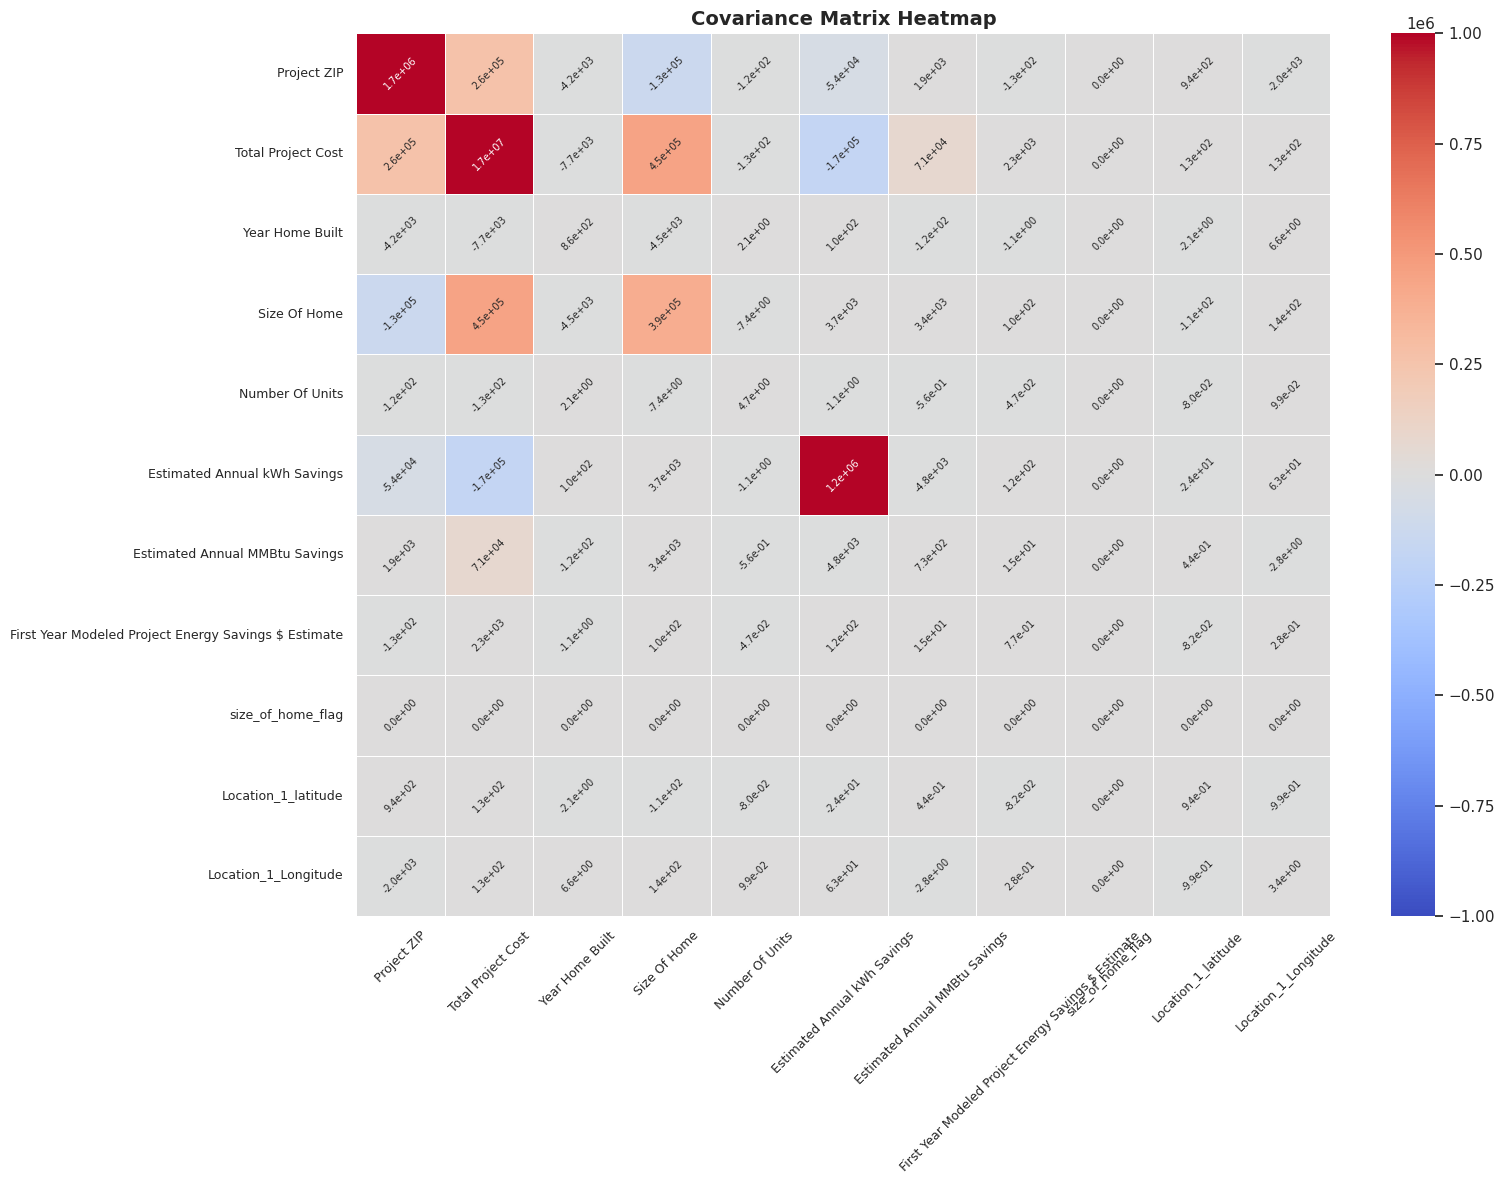

In [10]:
fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(
    cov_matrix,
    annot=True, fmt='.1e',
    annot_kws={"size": 7, "rotation": 45},
    cmap='coolwarm', center=0,
    vmin=-1e6, vmax=1e6,   # cap the scale so smaller values show contrast
    linewidths=0.5, ax=ax
)
ax.set_title('Covariance Matrix Heatmap', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', labelsize=9, rotation=45)
ax.tick_params(axis='y', labelsize=9, rotation=0)
plt.tight_layout()
plt.show()

###Pearson Correlation Matrix

In [11]:
corr_matrix = df[numeric_cols].corr(method='pearson')
print('Pearson Correlation Matrix:')
corr_matrix

Pearson Correlation Matrix:


,Project ZIP,Total Project Cost,Year Home Built,Size Of Home,Number Of Units,Estimated Annual kWh Savings,Estimated Annual MMBtu Savings,First Year Modeled Project Energy Savings $ Estimate,size_of_home_flag,Location_1_latitude,Location_1_Longitude
Project ZIP,1.0000,0.0485,-0.1105,-0.1580,-0.0433,-0.0380,0.0552,-0.1136,NaN,0.7467,-0.8434
Total Project Cost,0.0485,1.0000,-0.0633,0.1713,-0.0148,-0.0384,0.6305,0.6335,NaN,0.0325,0.0173
Year Home Built,-0.1105,-0.0633,1.0000,-0.2448,0.0324,0.0032,-0.1520,-0.0421,NaN,-0.0731,0.1222
Size Of Home,-0.1580,0.1713,-0.2448,1.0000,-0.0054,0.0053,0.2016,0.1857,NaN,-0.1856,0.1189
Number Of Units,-0.0433,-0.0148,0.0324,-0.0054,1.0000,-0.0005,-0.0095,-0.0246,NaN,-0.0379,0.0249
Estimated Annual kWh Savings,-0.0380,-0.0384,0.0032,0.0053,-0.0005,1.0000,-0.1620,0.1271,NaN,-0.0228,0.0315
Estimated Annual MMBtu Savings,0.0552,0.6305,-0.1520,0.2016,-0.0095,-0.1620,1.0000,0.6195,NaN,0.0168,-0.0567
First Year Modeled Project Energy Savings $ Estimate,-0.1136,0.6335,-0.0421,0.1857,-0.0246,0.1271,0.6195,1.0000,NaN,-0.0964,0.1761
size_of_home_flag,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location_1_latitude,0.7467,0.0325,-0.0731,-0.1856,-0.0379,-0.0228,0.0168,-0.0964,NaN,1.0000,-0.5586


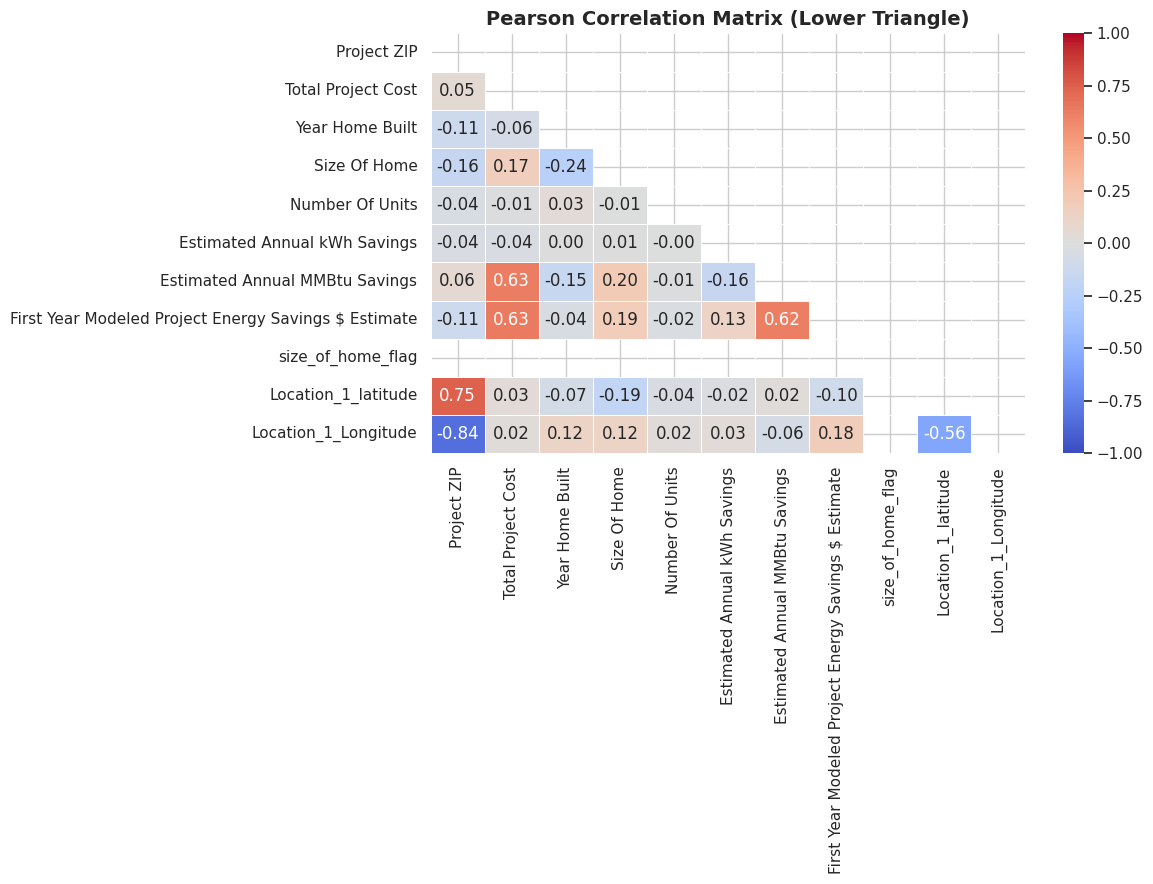

In [12]:
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1, center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('Pearson Correlation Matrix (Lower Triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

###Descriptive Stats — Categorical Fields

In [13]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')
print()
df[cat_cols].describe()

Categorical columns (11): ['Reporting Period', 'Project ID', 'Project County', 'Project City', 'Gas Utility', 'Electric Utility', 'Project Completion Date', 'Pre-Retrofit Home Heating Fuel Type', 'Job Type', 'Type Of Dwelling', 'Measure Type']



,Reporting Period,Project ID,Project County,Project City,Gas Utility,Electric Utility,Project Completion Date,Pre-Retrofit Home Heating Fuel Type,Job Type,Type Of Dwelling,Measure Type
count,51934,51934,51934,51934,51934,51934,51934,51934,51934,51934,51934
unique,1,51796,62,1532,12,8,845,9,2,3,3
top,2023-06-30,421927,Monroe,Rochester,National Grid,National Grid,2023-01-17,Natural Gas,Home Performance,Single Family,Building Shell
freq,51934,2,7533,6128,20584,21090,372,37343,49924,45580,51406


In [14]:
# Top-5 value counts for each categorical column
for col in cat_cols:
    print(f'--- {col} ---')
    print(df[col].value_counts().head(5).to_string())
    print()

--- Reporting Period ---
Reporting Period
2023-06-30    51934

--- Project ID ---
Project ID
421927    2
475873    2
535448    2
524364    2
545978    2

--- Project County ---
Project County
Monroe      7533
Erie        5776
Oneida      4225
Onondaga    3206
Kings       3175

--- Project City ---
Project City
Rochester    6128
Buffalo      3991
Brooklyn     3156
Queens       2619
Syracuse     1961

--- Gas Utility ---
Gas Utility
National Grid                     20584
National Fuel Gas Distribution     8993
Rochester Gas & Electric           8825
New York State Electric & Gas      8176
Consolidated Edison                1877

--- Electric Utility ---
Electric Utility
National Grid                    21090
New York State Electric & Gas     9374
Rochester Gas & Electric          8629
Consolidated Edison               7981
Orange & Rockland                 1832

--- Project Completion Date ---
Project Completion Date
2023-01-17    372
2022-05-12    360
2023-03-22    278
2023-04-13    27

---
## Task 2 — `House Age` Feature
**House Age = Current Year (2026) − Year Home Built**

In [15]:
CURRENT_YEAR = 2026

df['House Age'] = CURRENT_YEAR - df['Year Home Built']

print(f'House Age column created (Current Year: {CURRENT_YEAR})')
print(f'Range: {df["House Age"].min()} – {df["House Age"].max()} years')
print()
print(df[['Year Home Built', 'House Age']].head(10))

House Age column created (Current Year: 2026)
Range: 4 – 236 years

   Year Home Built  House Age
0             1960         66
1             1933         93
2             1944         82
3             1913        113
4             1901        125
5             1992         34
6             1884        142
7             1966         60
8             1994         32
9             1954         72


In [16]:
# Sanity check — any negative ages
neg = df[df['House Age'] < 0]
print(f'Rows with negative House Age: {len(neg)}')
if len(neg) > 0:
    print(neg[['Year Home Built', 'House Age']])

Rows with negative House Age: 0


In [17]:
print('House Age — Descriptive Statistics:')
print(df['House Age'].describe(percentiles=[.05, .25, .5, .75, .95]))
print(f'Variance : {df["House Age"].var():.4f}')
print(f'Skewness : {df["House Age"].skew():.4f}')
print(f'Kurtosis : {df["House Age"].kurt():.4f}')

House Age — Descriptive Statistics:
count   51934.0000
mean       77.8921
std        29.2954
min         4.0000
5%         32.0000
25%        60.0000
50%        78.0000
75%        95.0000
95%       124.0000
max       236.0000
Name: House Age, dtype: float64
Variance : 858.2207
Skewness : 0.5938
Kurtosis : 1.9628


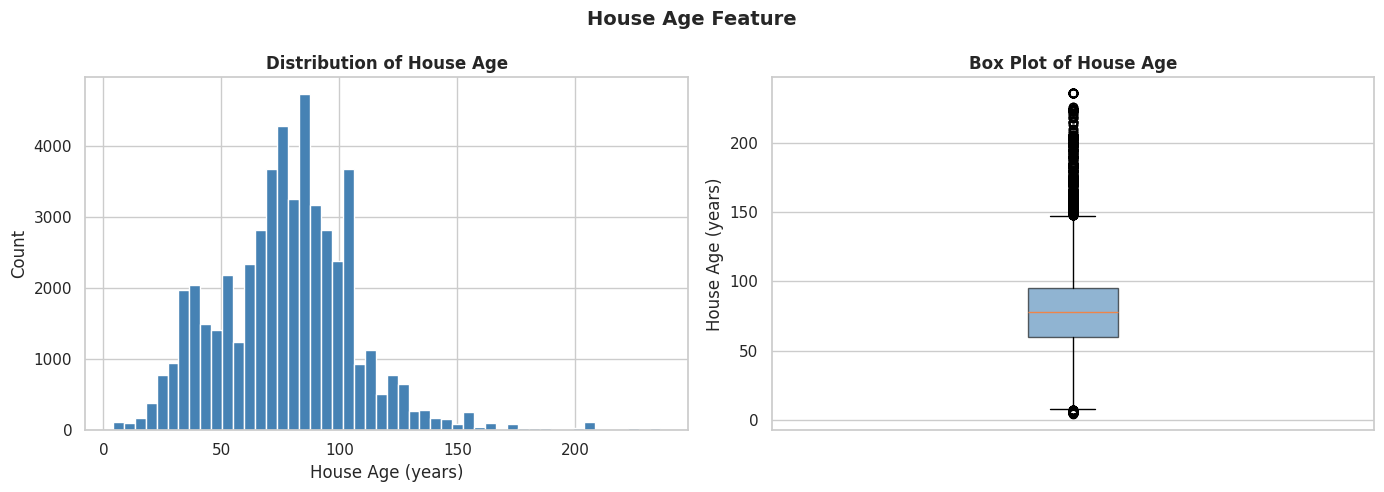

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(df['House Age'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of House Age', fontweight='bold')
axes[0].set_xlabel('House Age (years)')
axes[0].set_ylabel('Count')

# Box plot
axes[1].boxplot(df['House Age'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Box Plot of House Age', fontweight='bold')
axes[1].set_ylabel('House Age (years)')
axes[1].set_xticks([])

plt.suptitle('House Age Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Task 3 — ANOVA Test & VIF on the Transformed Dataset

**ANOVA** tests whether group means of a numeric target differ significantly across categorical groups.  
**VIF** (Variance Inflation Factor) detects multicollinearity among numeric predictors.

In [19]:
# Refreshed numeric columns (now includes House Age)
numeric_cols_updated = df.select_dtypes(include='number').columns.tolist()
print(f'Numeric columns after transformation ({len(numeric_cols_updated)}):')
print(numeric_cols_updated)

Numeric columns after transformation (12):
['Project ZIP', 'Total Project Cost', 'Year Home Built', 'Size Of Home', 'Number Of Units', 'Estimated Annual kWh Savings', 'Estimated Annual MMBtu Savings', 'First Year Modeled Project Energy Savings $ Estimate', 'size_of_home_flag', 'Location_1_latitude', 'Location_1_Longitude', 'House Age']


###One-Way ANOVA
For each **categorical** grouping variable, we test whether the means of key **numeric** targets differ across groups.  
H₀: All group means are equal | H₁: At least one group mean differs  
α = 0.05

In [20]:
# Numeric targets we care about for ANOVA
anova_targets = [
    'Total Project Cost',
    'Estimated Annual kWh Savings',
    'Estimated Annual MMBtu Savings',
    'First Year Modeled Project Energy Savings $ Estimate',
    'House Age',
    'Size Of Home'
]

# Categorical grouping variables
anova_groups = [
    'Job Type',
    'Type Of Dwelling',
    'Measure Type',
    'Pre-Retrofit Home Heating Fuel Type'
]

# Filter to columns that actually exist
anova_targets = [c for c in anova_targets if c in df.columns]
anova_groups  = [c for c in anova_groups  if c in df.columns]

print('ANOVA Targets :', anova_targets)
print('ANOVA Groups  :', anova_groups)

ANOVA Targets : ['Total Project Cost', 'Estimated Annual kWh Savings', 'Estimated Annual MMBtu Savings', 'First Year Modeled Project Energy Savings $ Estimate', 'House Age', 'Size Of Home']
ANOVA Groups  : ['Job Type', 'Type Of Dwelling', 'Measure Type', 'Pre-Retrofit Home Heating Fuel Type']


In [21]:
anova_results = []

for group_col in anova_groups:
    for target_col in anova_targets:
        # Build a list of arrays — one per group level
        groups = [
            grp[target_col].dropna().values
            for _, grp in df.groupby(group_col)
            if len(grp[target_col].dropna()) > 1
        ]

        if len(groups) < 2:
            continue  # Need at least 2 groups

        f_stat, p_val = f_oneway(*groups)

        # Levene's test for equality of variances
        lev_stat, lev_p = levene(*groups)

        anova_results.append({
            'Group Variable'   : group_col,
            'Target Variable'  : target_col,
            'Num Groups'       : len(groups),
            'F-Statistic'      : round(f_stat, 4),
            'p-value'          : round(p_val, 6),
            'Significant (α=0.05)': 'Yes' if p_val < 0.05 else 'No',
            "Levene's p-value" : round(lev_p, 6),
            'Equal Variances'  : 'Yes' if lev_p >= 0.05 else 'No'
        })

anova_df = pd.DataFrame(anova_results)
print(f'Total ANOVA tests run: {len(anova_df)}')
anova_df

Total ANOVA tests run: 24


,Group Variable,Target Variable,Num Groups,F-Statistic,p-value,Significant (α=0.05),Levene's p-value,Equal Variances
0,Job Type,Total Project Cost,2,4005.2790,0.0000,Yes,0.0000,No
1,Job Type,Estimated Annual kWh Savings,2,0.1387,0.7096,No,0.0000,No
2,Job Type,Estimated Annual MMBtu Savings,2,2567.1624,0.0000,Yes,0.0000,No
3,Job Type,First Year Modeled Project Energy Savings $ Es...,2,4753.3116,0.0000,Yes,0.0000,No
4,Job Type,House Age,2,467.5794,0.0000,Yes,0.0000,No
5,Job Type,Size Of Home,2,741.9295,0.0000,Yes,0.0000,No
6,Type Of Dwelling,Total Project Cost,3,57.5661,0.0000,Yes,0.0000,No
7,Type Of Dwelling,Estimated Annual kWh Savings,3,2.2340,0.1071,No,0.7407,Yes
8,Type Of Dwelling,Estimated Annual MMBtu Savings,3,131.7280,0.0000,Yes,0.0000,No
9,Type Of Dwelling,First Year Modeled Project Energy Savings $ Es...,3,159.6734,0.0000,Yes,0.0000,No


In [22]:
print('=== Summary: Significant Results (p < 0.05) ===')
sig = anova_df[anova_df['Significant (α=0.05)'] == 'Yes']
print(f'{len(sig)} out of {len(anova_df)} tests are significant.')
sig[['Group Variable', 'Target Variable', 'F-Statistic', 'p-value']]

=== Summary: Significant Results (p < 0.05) ===
16 out of 24 tests are significant.


,Group Variable,Target Variable,F-Statistic,p-value
0,Job Type,Total Project Cost,4005.2790,0.0000
2,Job Type,Estimated Annual MMBtu Savings,2567.1624,0.0000
3,Job Type,First Year Modeled Project Energy Savings $ Es...,4753.3116,0.0000
4,Job Type,House Age,467.5794,0.0000
5,Job Type,Size Of Home,741.9295,0.0000
6,Type Of Dwelling,Total Project Cost,57.5661,0.0000
8,Type Of Dwelling,Estimated Annual MMBtu Savings,131.7280,0.0000
9,Type Of Dwelling,First Year Modeled Project Energy Savings $ Es...,159.6734,0.0000
10,Type Of Dwelling,House Age,8573.6561,0.0000
11,Type Of Dwelling,Size Of Home,2073.2557,0.0000


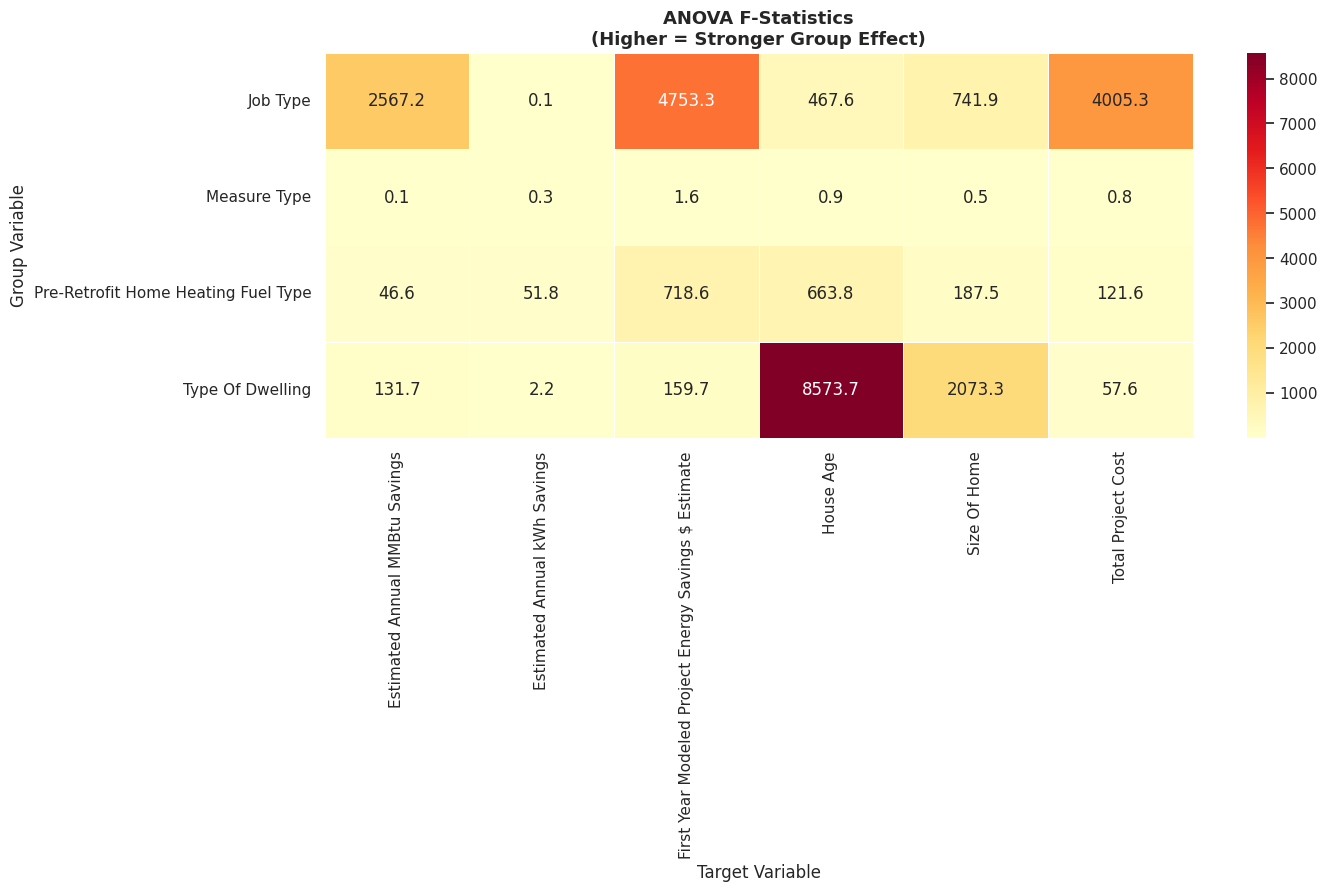

In [23]:
# Visualize F-statistics as a heatmap
pivot_f = anova_df.pivot(index='Group Variable', columns='Target Variable', values='F-Statistic')
pivot_p = anova_df.pivot(index='Group Variable', columns='Target Variable', values='p-value')

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    pivot_f,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax
)
ax.set_title('ANOVA F-Statistics\n(Higher = Stronger Group Effect)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

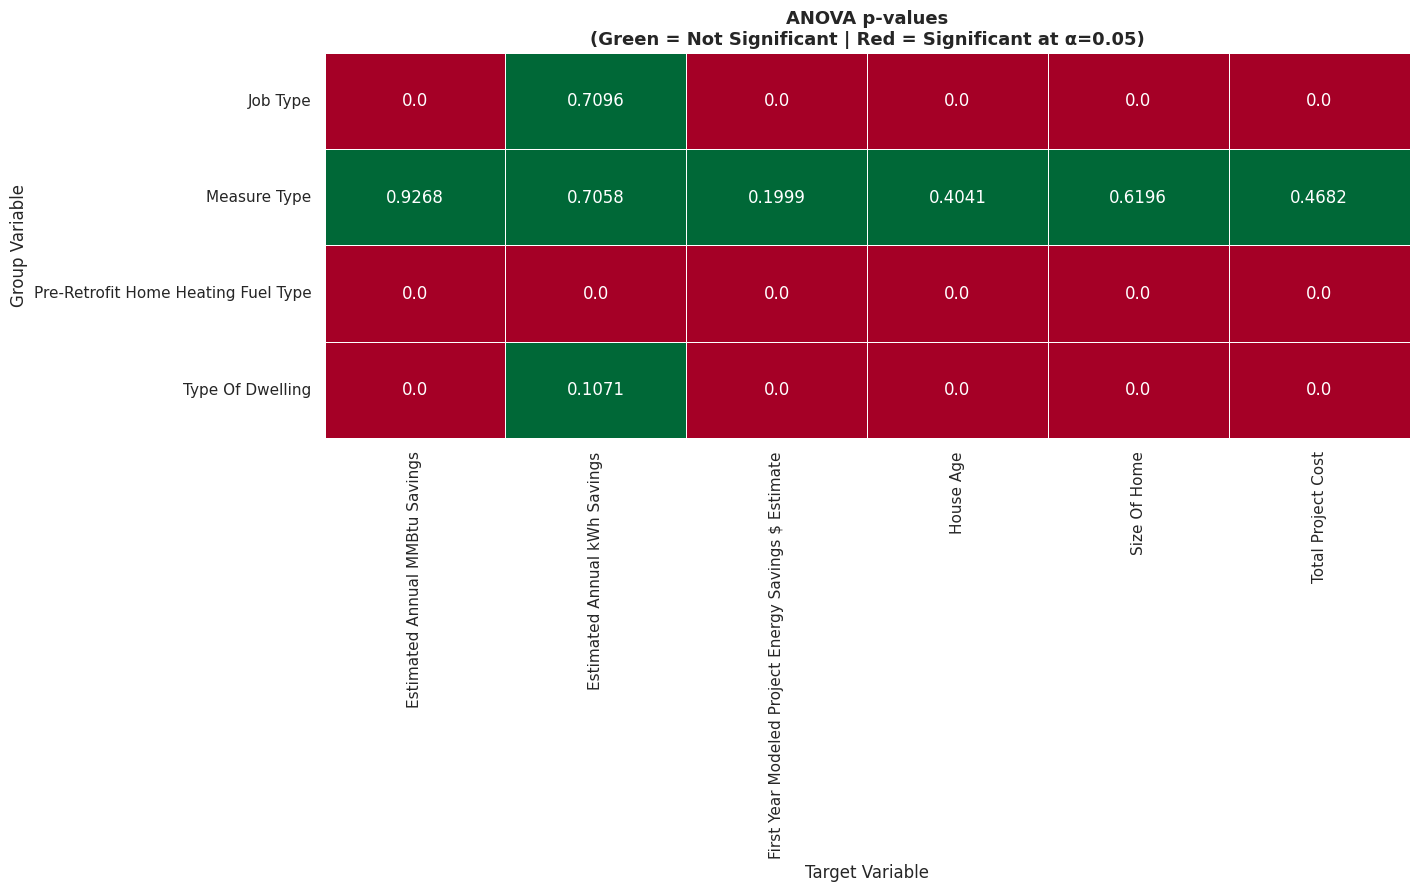

In [24]:
# p-value significance heatmap
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    pivot_p < 0.05,     # Boolean: True = significant
    annot=pivot_p.round(4),
    fmt='',
    cmap='RdYlGn_r',
    linewidths=0.5,
    ax=ax,
    cbar=False
)
ax.set_title('ANOVA p-values\n(Green = Not Significant | Red = Significant at α=0.05)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

###Variance Inflation Factor (VIF)
VIF measures multicollinearity among numeric predictors.  
- **VIF < 5**: Low multicollinearity
- **5 ≤ VIF < 10**: Moderate multicollinearity  
- **VIF ≥ 10**: High multicollinearity

In [25]:
# Select numeric columns with no missing values for VIF
vif_cols = df[numeric_cols_updated].dropna(axis=1).copy()

# Drop columns with zero variance (constant columns cause singular matrices)
vif_cols = vif_cols.loc[:, vif_cols.var() > 0]

# Drop rows with any NaN
vif_cols = vif_cols.dropna()

print(f'Columns used for VIF ({len(vif_cols.columns)}): {list(vif_cols.columns)}')
print(f'Rows after dropping NaN: {len(vif_cols):,}')

Columns used for VIF (10): ['Project ZIP', 'Total Project Cost', 'Year Home Built', 'Size Of Home', 'Number Of Units', 'Estimated Annual kWh Savings', 'Estimated Annual MMBtu Savings', 'Location_1_latitude', 'Location_1_Longitude', 'House Age']
Rows after dropping NaN: 51,934


In [27]:
X_vif = add_constant(vif_cols)

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF']     = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

# Exclude the constant row for display
vif_data = vif_data[vif_data['Feature'] != 'const'].reset_index(drop=True)
vif_data['VIF'] = vif_data['VIF'].round(4)

def vif_label(v):
    if v < 5:   return 'Low'
    if v < 10:  return 'Moderate'
    return 'High'

vif_data['Collinearity Level'] = vif_data['VIF'].apply(vif_label)
vif_data_sorted = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print('VIF Results:')
vif_data_sorted

VIF Results:


,Feature,VIF,Collinearity Level
0,House Age,inf,High
1,Year Home Built,inf,High
2,Project ZIP,5.7119,Moderate
3,Location_1_Longitude,3.7056,Low
4,Location_1_latitude,2.3790,Low
5,Estimated Annual MMBtu Savings,1.7889,Low
6,Total Project Cost,1.7264,Low
7,Size Of Home,1.1614,Low
8,Estimated Annual kWh Savings,1.0368,Low
9,Number Of Units,1.0033,Low


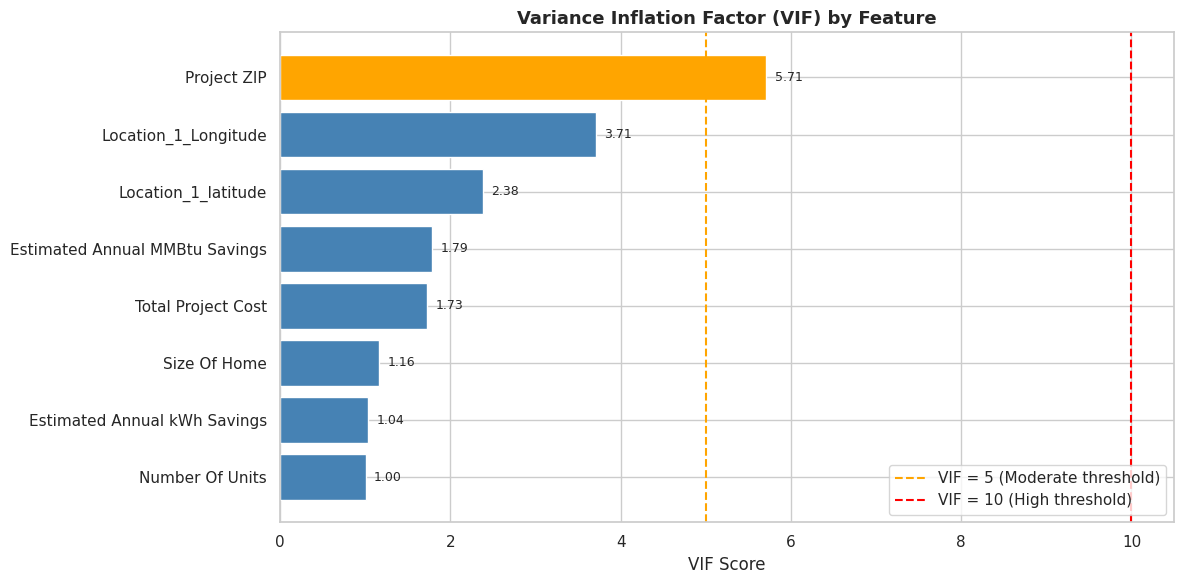

In [28]:
# Bar chart of VIF values
colors = [
    'crimson' if v >= 10 else 'orange' if v >= 5 else 'steelblue'
    for v in vif_data_sorted['VIF']
]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(vif_data_sorted['Feature'], vif_data_sorted['VIF'], color=colors, edgecolor='white')

# Reference lines
ax.axvline(5,  color='orange', linestyle='--', linewidth=1.5, label='VIF = 5 (Moderate threshold)')
ax.axvline(10, color='red',    linestyle='--', linewidth=1.5, label='VIF = 10 (High threshold)')

for bar, val in zip(bars, vif_data_sorted['VIF']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

ax.set_xlabel('VIF Score')
ax.set_title('Variance Inflation Factor (VIF) by Feature', fontweight='bold', fontsize=13)
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

In [29]:
print('=== VIF Summary ===')
print(f"Low multicollinearity  (VIF < 5)  : {(vif_data['VIF'] < 5).sum()} features")
print(f"Moderate               (5 ≤ VIF < 10): {((vif_data['VIF'] >= 5) & (vif_data['VIF'] < 10)).sum()} features")
print(f"High multicollinearity (VIF ≥ 10) : {(vif_data['VIF'] >= 10).sum()} features")
print()
print('Features with High VIF (consider removing for regression):')
high_vif = vif_data[vif_data['VIF'] >= 10].sort_values('VIF', ascending=False)
print(high_vif[['Feature', 'VIF']].to_string(index=False) if len(high_vif) > 0 else 'None')

=== VIF Summary ===
Low multicollinearity  (VIF < 5)  : 7 features
Moderate               (5 ≤ VIF < 10): 1 features
High multicollinearity (VIF ≥ 10) : 2 features

Features with High VIF (consider removing for regression):
        Feature  VIF
Year Home Built  inf
      House Age  inf


### Target Variable Analysis

  TARGET: Total Project Cost
  Count       : 51,934
  Mean        : 6,432.4408
  Median      : 5,926.0000
  Std Dev     : 4,154.1317
  Variance    : 17,256,810.1170
  Skewness    : 2.1734
  Kurtosis    : 15.7993
  Min         : 129.0000
  Max         : 92,297.0000

  NORMALITY TESTS
  ----------------------------------------
  Kolmogorov-Smirnov : stat=0.0756, p=0.000000
  Normal Distribution: No (α=0.05)

  D'Agostino-Pearson : stat=28182.2686, p=0.000000
  Normal Distribution: No (α=0.05)

  D'Agostino-Pearson (log-transformed): stat=8722.5376, p=0.000000
  More normal after log transform: No


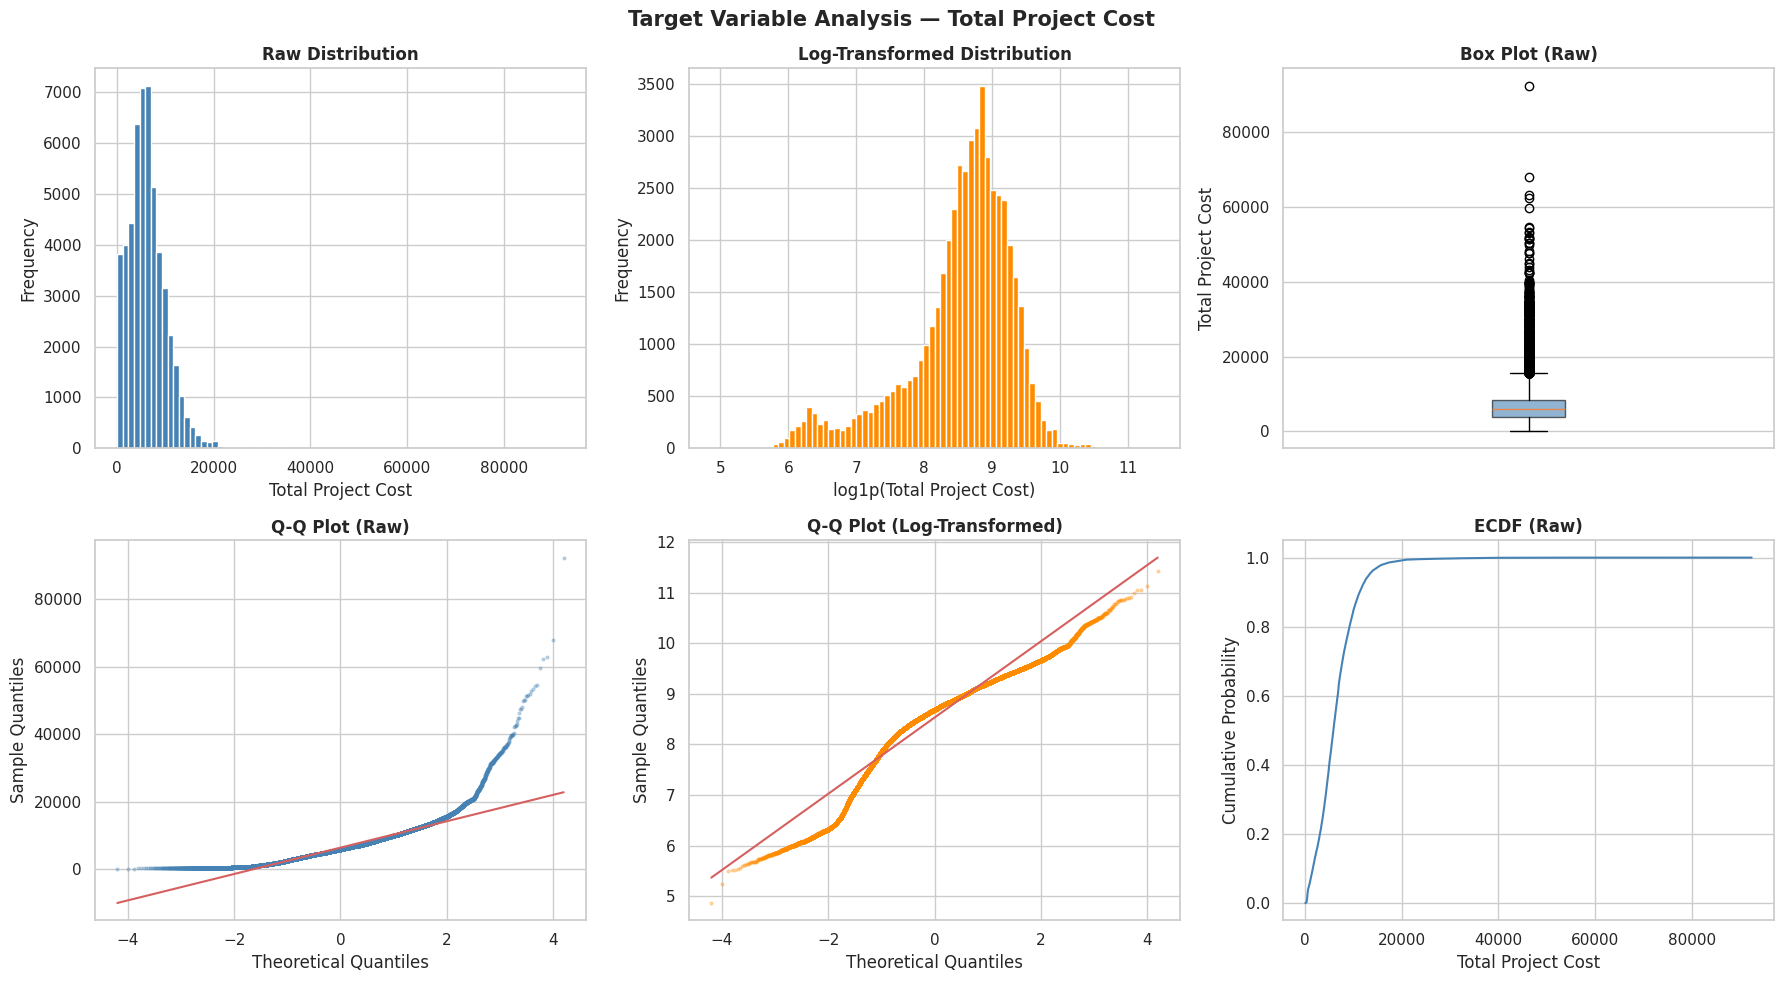

In [31]:
TARGET = 'Total Project Cost'  # change if needed

target = df[TARGET].dropna()

# --- Descriptive Stats ---
print(f"{'='*55}")
print(f"  TARGET: {TARGET}")
print(f"{'='*55}")
print(f"  Count       : {len(target):,}")
print(f"  Mean        : {target.mean():,.4f}")
print(f"  Median      : {target.median():,.4f}")
print(f"  Std Dev     : {target.std():,.4f}")
print(f"  Variance    : {target.var():,.4f}")
print(f"  Skewness    : {target.skew():.4f}")
print(f"  Kurtosis    : {target.kurt():.4f}")
print(f"  Min         : {target.min():,.4f}")
print(f"  Max         : {target.max():,.4f}")
print(f"{'='*55}")

# --- Normality Tests ---
print("\n  NORMALITY TESTS")
print(f"  {'-'*40}")

# Kolmogorov-Smirnov (use on large samples instead of Shapiro)
ks_stat, ks_p = stats.kstest(target, 'norm',
                              args=(target.mean(), target.std()))
print(f"  Kolmogorov-Smirnov : stat={ks_stat:.4f}, p={ks_p:.6f}")
print(f"  Normal Distribution: {'No' if ks_p < 0.05 else 'Yes'} (α=0.05)")

# D'Agostino-Pearson (tests skew + kurtosis jointly)
dp_stat, dp_p = stats.normaltest(target)
print(f"\n  D'Agostino-Pearson : stat={dp_stat:.4f}, p={dp_p:.6f}")
print(f"  Normal Distribution: {'No' if dp_p < 0.05 else 'Yes'} (α=0.05)")

# --- Log Transform Check ---
target_log = np.log1p(target[target > 0])
dp_stat_log, dp_p_log = stats.normaltest(target_log)
print(f"\n  D'Agostino-Pearson (log-transformed): stat={dp_stat_log:.4f}, p={dp_p_log:.6f}")
print(f"  More normal after log transform: {'Yes' if dp_p_log > dp_p else 'No'}")

# --- Plots ---
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 3, figure=fig)

# Raw histogram
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(target, bins=80, color='steelblue', edgecolor='white')
ax1.set_title('Raw Distribution', fontweight='bold')
ax1.set_xlabel(TARGET)
ax1.set_ylabel('Frequency')

# Log-transformed histogram
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(target_log, bins=80, color='darkorange', edgecolor='white')
ax2.set_title('Log-Transformed Distribution', fontweight='bold')
ax2.set_xlabel(f'log1p({TARGET})')
ax2.set_ylabel('Frequency')

# Box plot raw
ax3 = fig.add_subplot(gs[0, 2])
ax3.boxplot(target, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6))
ax3.set_title('Box Plot (Raw)', fontweight='bold')
ax3.set_ylabel(TARGET)
ax3.set_xticks([])

# Q-Q plot raw
ax4 = fig.add_subplot(gs[1, 0])
(osm, osr), (slope, intercept, r) = stats.probplot(target, dist='norm')
ax4.plot(osm, osr, 'o', color='steelblue', alpha=0.3, markersize=2)
ax4.plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=1.5)
ax4.set_title('Q-Q Plot (Raw)', fontweight='bold')
ax4.set_xlabel('Theoretical Quantiles')
ax4.set_ylabel('Sample Quantiles')

# Q-Q plot log
ax5 = fig.add_subplot(gs[1, 1])
(osm_log, osr_log), (slope_log, intercept_log, r_log) = stats.probplot(target_log, dist='norm')
ax5.plot(osm_log, osr_log, 'o', color='darkorange', alpha=0.3, markersize=2)
ax5.plot(osm_log, slope_log * np.array(osm_log) + intercept_log, 'r-', linewidth=1.5)
ax5.set_title('Q-Q Plot (Log-Transformed)', fontweight='bold')
ax5.set_xlabel('Theoretical Quantiles')
ax5.set_ylabel('Sample Quantiles')

# ECDF
ax6 = fig.add_subplot(gs[1, 2])
sorted_data = np.sort(target)
ecdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
ax6.plot(sorted_data, ecdf, color='steelblue', linewidth=1.5)
ax6.set_title('ECDF (Raw)', fontweight='bold')
ax6.set_xlabel(TARGET)
ax6.set_ylabel('Cumulative Probability')

fig.suptitle(f'Target Variable Analysis — {TARGET}', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Outlier Analysis

Outlier Summary (sorted by IQR Outlier %):
                                             Feature  IQR Outliers  IQR Outlier %  Z-Score Outliers  Z-Score %
                        Estimated Annual kWh Savings          4943         9.5200               802     1.5400
                                        Size Of Home          1772         3.4100               976     1.8800
                      Estimated Annual MMBtu Savings          1529         2.9400               523     1.0100
                                  Total Project Cost          1228         2.3600               544     1.0500
                                     Year Home Built          1064         2.0500               476     0.9200
                                           House Age          1064         2.0500               476     0.9200
                                     Number Of Units           923         1.7800                47     0.0900
First Year Modeled Project Energy Savings $ Estimate           913   

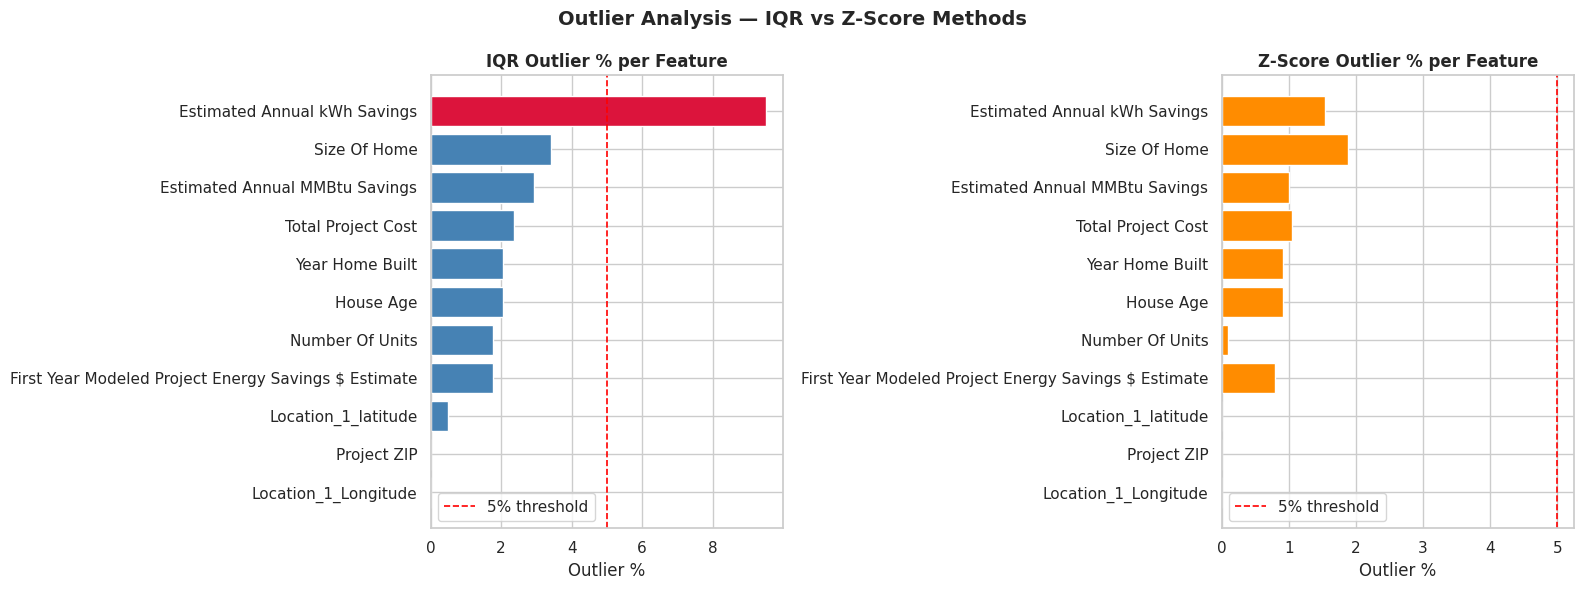

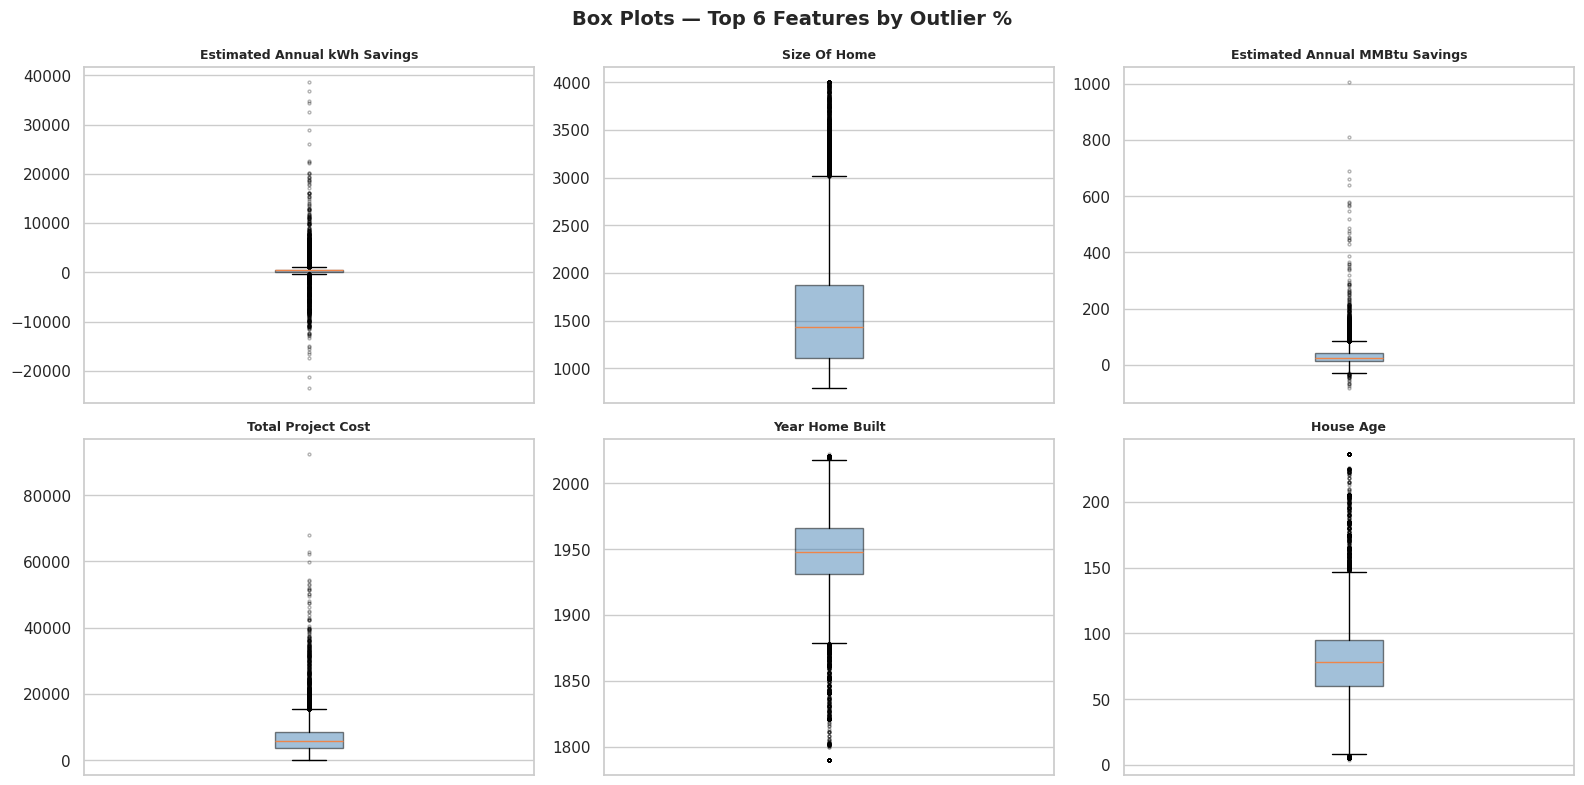

In [32]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
# Drop zero-variance columns
numeric_cols = [c for c in numeric_cols if df[c].var() > 0]

Z_THRESH  = 3.0
IQR_MULT  = 1.5

outlier_summary = []

for col in numeric_cols:
    series = df[col].dropna()

    # IQR method
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    iqr_mask  = (series < Q1 - IQR_MULT * IQR) | (series > Q3 + IQR_MULT * IQR)
    iqr_count = iqr_mask.sum()

    # Z-score method
    z_scores  = np.abs(stats.zscore(series))
    z_count   = (z_scores > Z_THRESH).sum()

    outlier_summary.append({
        'Feature'          : col,
        'IQR Outliers'     : iqr_count,
        'IQR Outlier %'    : round(iqr_count / len(series) * 100, 2),
        'Z-Score Outliers' : z_count,
        'Z-Score %'        : round(z_count / len(series) * 100, 2),
        'Q1'               : round(Q1, 2),
        'Q3'               : round(Q3, 2),
        'IQR'              : round(IQR, 2),
        'Lower Fence'      : round(Q1 - IQR_MULT * IQR, 2),
        'Upper Fence'      : round(Q3 + IQR_MULT * IQR, 2),
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('IQR Outlier %', ascending=False)
outlier_df = outlier_df.reset_index(drop=True)

print("Outlier Summary (sorted by IQR Outlier %):")
print(outlier_df[['Feature', 'IQR Outliers', 'IQR Outlier %',
                   'Z-Score Outliers', 'Z-Score %']].to_string(index=False))

# --- Bar chart: outlier % per feature ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_iqr = ['crimson' if x > 5 else 'steelblue' for x in outlier_df['IQR Outlier %']]
axes[0].barh(outlier_df['Feature'], outlier_df['IQR Outlier %'],
             color=colors_iqr, edgecolor='white')
axes[0].axvline(5, color='red', linestyle='--', linewidth=1.2, label='5% threshold')
axes[0].set_title('IQR Outlier % per Feature', fontweight='bold')
axes[0].set_xlabel('Outlier %')
axes[0].invert_yaxis()
axes[0].legend()

colors_z = ['crimson' if x > 5 else 'darkorange' for x in outlier_df['Z-Score %']]
axes[1].barh(outlier_df['Feature'], outlier_df['Z-Score %'],
             color=colors_z, edgecolor='white')
axes[1].axvline(5, color='red', linestyle='--', linewidth=1.2, label='5% threshold')
axes[1].set_title('Z-Score Outlier % per Feature', fontweight='bold')
axes[1].set_xlabel('Outlier %')
axes[1].invert_yaxis()
axes[1].legend()

plt.suptitle('Outlier Analysis — IQR vs Z-Score Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Box plots for top outlier features ---
top_features = outlier_df.head(6)['Feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(top_features):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.5),
                    flierprops=dict(marker='o', markersize=2,
                                   alpha=0.3, color='crimson'))
    axes[i].set_title(col, fontweight='bold', fontsize=9)
    axes[i].set_xticks([])

plt.suptitle('Box Plots — Top 6 Features by Outlier %', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Feature-Target Deep Dive

Feature-Target Correlations with: Total Project Cost
                                             Feature  Pearson r  Pearson p  Spearman r  Spearman p  Gap (|Sp|-|Pe|) Pearson Sig Spearman Sig Non-linear Signal
                      Estimated Annual MMBtu Savings     0.6305     0.0000      0.7361      0.0000           0.1056         Yes          Yes               Yes
First Year Modeled Project Energy Savings $ Estimate     0.6335     0.0000      0.7108      0.0000           0.0773         Yes          Yes               Yes
                                        Size Of Home     0.1713     0.0000      0.1812      0.0000           0.0098         Yes          Yes                No
                        Estimated Annual kWh Savings    -0.0384     0.0000      0.0780      0.0000           0.0396         Yes          Yes                No
                                           House Age     0.0633     0.0000      0.0716      0.0000           0.0083         Yes          Yes            

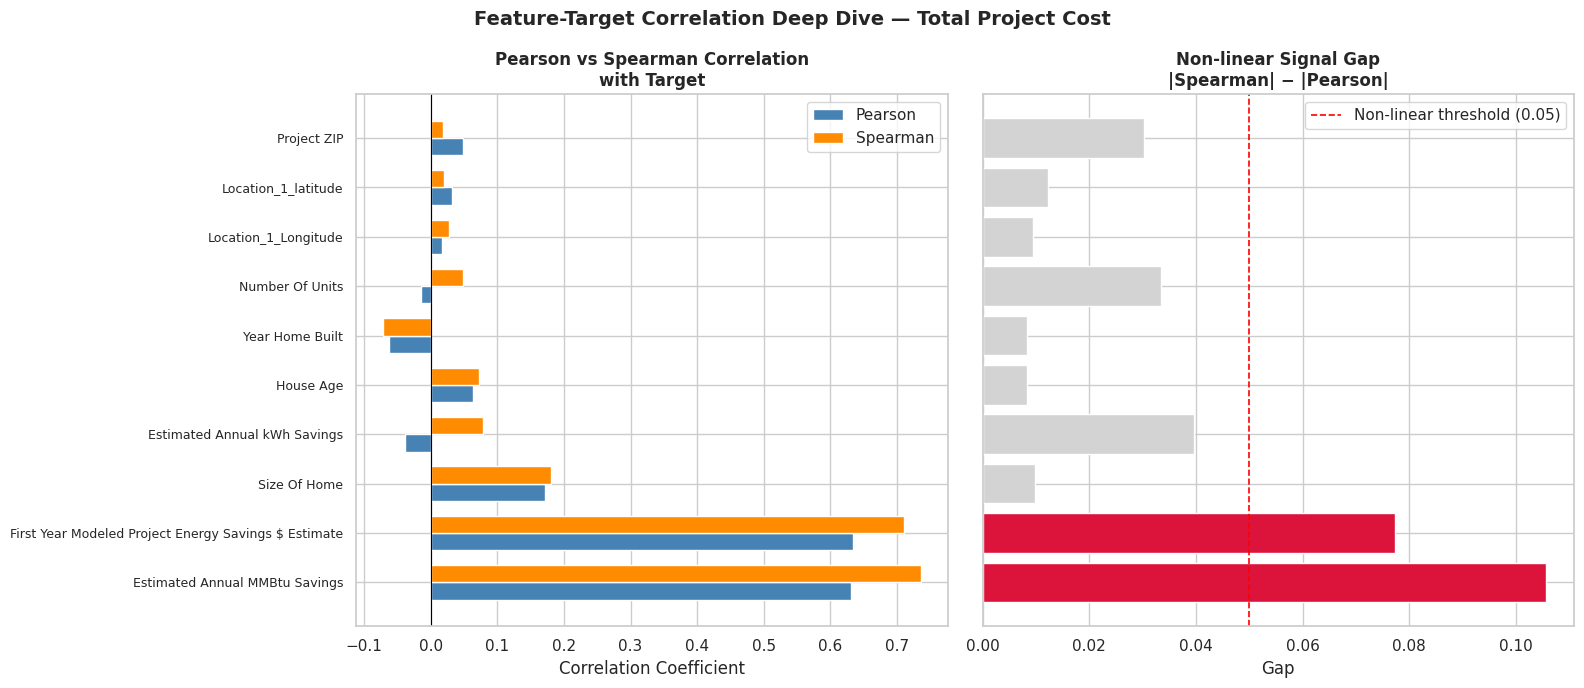

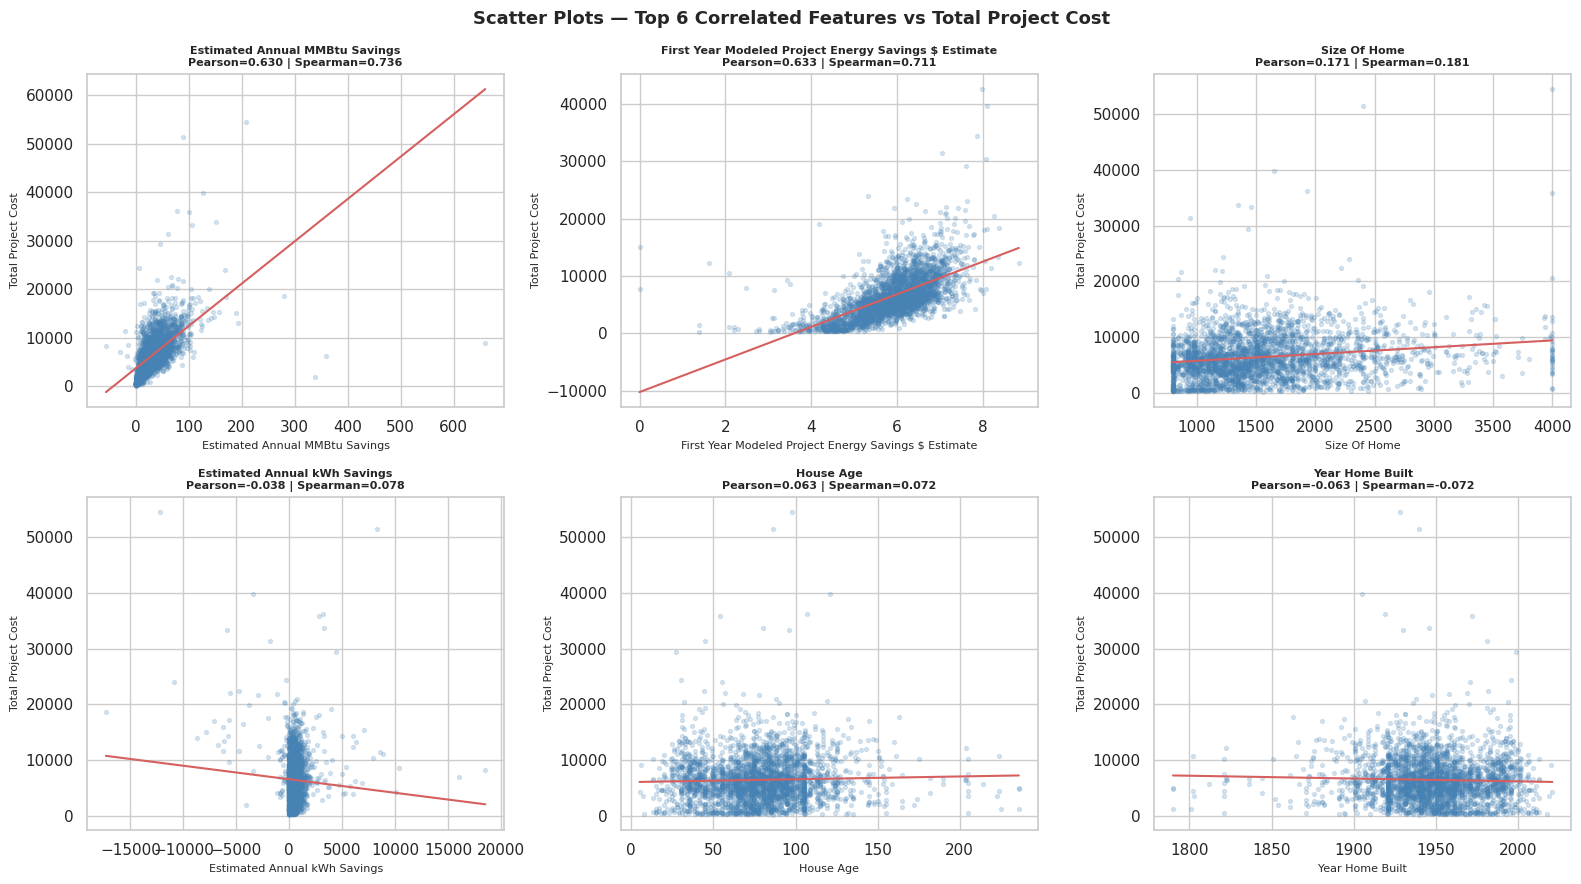

In [33]:
TARGET = 'Total Project Cost'  # change if needed

numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols = [c for c in numeric_cols if c != TARGET and df[c].var() > 0]

target_series = df[TARGET].dropna()

corr_results = []

for col in numeric_cols:
    aligned = df[[col, TARGET]].dropna()
    x = aligned[col]
    y = aligned[TARGET]

    pearson_r,  pearson_p  = stats.pearsonr(x, y)
    spearman_r, spearman_p = stats.spearmanr(x, y)
    gap = abs(abs(spearman_r) - abs(pearson_r))

    corr_results.append({
        'Feature'              : col,
        'Pearson r'            : round(pearson_r, 4),
        'Pearson p'            : round(pearson_p, 6),
        'Spearman r'           : round(spearman_r, 4),
        'Spearman p'           : round(spearman_p, 6),
        'Gap (|Sp|-|Pe|)'      : round(gap, 4),
        'Pearson Sig'          : 'Yes' if pearson_p  < 0.05 else 'No',
        'Spearman Sig'         : 'Yes' if spearman_p < 0.05 else 'No',
        'Non-linear Signal'    : 'Yes' if gap > 0.05 else 'No',
    })

corr_df = pd.DataFrame(corr_results).sort_values('Spearman r',
                                                   key=abs, ascending=False)
corr_df = corr_df.reset_index(drop=True)

print(f"Feature-Target Correlations with: {TARGET}")
print(corr_df.to_string(index=False))

print(f"\nFeatures with strong non-linear signal (Gap > 0.05):")
nl = corr_df[corr_df['Non-linear Signal'] == 'Yes']
print(nl[['Feature', 'Pearson r', 'Spearman r', 'Gap (|Sp|-|Pe|)']].to_string(index=False)
      if len(nl) > 0 else "None detected")

# --- Diverging bar chart: Pearson vs Spearman ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

features = corr_df['Feature']
x = np.arange(len(features))
bar_w = 0.35

axes[0].barh(x - bar_w/2, corr_df['Pearson r'],  bar_w,
             label='Pearson',  color='steelblue',  edgecolor='white')
axes[0].barh(x + bar_w/2, corr_df['Spearman r'], bar_w,
             label='Spearman', color='darkorange', edgecolor='white')
axes[0].set_yticks(x)
axes[0].set_yticklabels(features, fontsize=9)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Pearson vs Spearman Correlation\nwith Target', fontweight='bold')
axes[0].set_xlabel('Correlation Coefficient')
axes[0].legend()
axes[0].invert_yaxis()

# Gap chart — highlights non-linearity
gap_colors = ['crimson' if g > 0.05 else 'lightgrey' for g in corr_df['Gap (|Sp|-|Pe|)']]
axes[1].barh(x, corr_df['Gap (|Sp|-|Pe|)'], color=gap_colors, edgecolor='white')
axes[1].set_yticks(x)
axes[1].set_yticklabels(features, fontsize=9)
axes[1].axvline(0.05, color='red', linestyle='--',
                linewidth=1.2, label='Non-linear threshold (0.05)')
axes[1].set_title('Non-linear Signal Gap\n|Spearman| − |Pearson|', fontweight='bold')
axes[1].set_xlabel('Gap')
axes[1].legend()
axes[1].invert_yaxis()

plt.suptitle(f'Feature-Target Correlation Deep Dive — {TARGET}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Scatter plots for top correlated features ---
top_feats = corr_df.head(6)['Feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(top_feats):
    aligned = df[[col, TARGET]].dropna().sample(min(3000, len(df)), random_state=42)
    axes[i].scatter(aligned[col], aligned[TARGET],
                    alpha=0.2, s=8, color='steelblue')
    # Regression line
    m, b = np.polyfit(aligned[col], aligned[TARGET], 1)
    x_line = np.linspace(aligned[col].min(), aligned[col].max(), 100)
    axes[i].plot(x_line, m * x_line + b, 'r-', linewidth=1.5)

    pe = corr_df.loc[corr_df['Feature'] == col, 'Pearson r'].values[0]
    sp = corr_df.loc[corr_df['Feature'] == col, 'Spearman r'].values[0]
    axes[i].set_title(f'{col}\nPearson={pe:.3f} | Spearman={sp:.3f}',
                      fontsize=8, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel(TARGET, fontsize=8)

plt.suptitle(f'Scatter Plots — Top 6 Correlated Features vs {TARGET}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Descriptive Analysis — Summary & Takeaways
---
## Target Variable
Total Project Cost is severely right-skewed (skewness=2.17, kurtosis=15.8) with values ranging from 129 to 92,297. Critically, even log transformation fails to normalize it. This directly disadvantages OLS and Lasso whose residual normality assumptions are violated from the start. RF and FFNN carry no such assumption.

**Action:** Train all four models on both raw and log1p-transformed target, compare RMSE on original scale after back-transforming.

---
## Outliers
Only two features need attention. "Estimated Annual kWh Savings" at 9.52% IQR outliers is a shape problem — log transform it. "Total Project Cost" at 2.36% has genuine extreme values that will disproportionately drag OLS and Lasso coefficients via squared error minimization. RF is naturally robust to both. FFNN robustness depends on loss function choice.

**Action:** Log-transform kWh Savings. Winsorize Total Project Cost at 99th percentile as an OLS sensitivity check. Drop "Year Home Built" — identical outlier profile to House Age, completely redundant.

---
## Feature-Target Correlations
Only two features correlate meaningfully with the target — "MMBtu Savings" (Spearman=0.74) and "First Year Energy Savings" (Spearman=0.71). Everything else is below 0.18 and significant only due to sample size, not practical relevance. Both strong features show non-linear signal with gaps above the 0.05 threshold, meaning linear models will systematically misfit them.

**Action:** After fitting RF, verify these two dominate feature importances. For OLS/Lasso, plot residuals against these features specifically — you should see systematic curves confirming non-linearity, which becomes your core model comparison argument.

---
## The Bottom Line
This dataset naturally favors non-linear models. Our two strongest predictors have non-linear relationships with a non-normal target surrounded by mostly weak features. We can frame our model comparison around one central question — **how much does non-linearity in the dominant predictors disadvantage OLS and Lasso relative to RF and FFNN** — and our descriptive analysis has already given you the evidence to answer it.